In [1]:
import warnings
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import percentileofscore
from statsmodels.stats.proportion import proportion_confint   
import statsmodels.api as sm

warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None

## Configuration

In [2]:
DB_DIR = "../example_data"

PATTERN_MATCHES_DB = f"{DB_DIR}/pattern_matches.db"

# root sõnade count tabel
OBL_TRANSACTIONS_ACTOR_ROOT_COUNTS = "trans_actor_eluskoht_root_count"

# verbide count tabel
OBL_TRANSACTIONS_ACTOR_VERB_COUNTS = "trans_actor_eluskoht_verb_count"

#or alternatively for original data
GRAPH_DATA_DIR = "graph_data_files/"
ORIGINAL_ROOT_COUNT_FILE = f"{GRAPH_DATA_DIR}verbs_wcomps_obl_actor_root_perloc_counts.csv"


## Connect to db

In [ ]:
con = sqlite3.connect(PATTERN_MATCHES_DB)
cur = con.cursor()

## Workflow

In [ ]:
query = """SELECT * from {tbl}""".format(tbl=OBL_TRANSACTIONS_ACTOR_ROOT_COUNTS)
source3 = pd.read_sql_query(query, con)
source3

Or alternatively

In [3]:
source3 = pd.read_csv(ORIGINAL_ROOT_COUNT_FILE, sep=",", encoding="utf-8")
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt
0,,5,0,0
1,%p2tu,1,0,0
2,%reimo,1,0,0
3,/O,2,0,0
4,/P,1,0,0
...,...,...,...,...
410714,█████████,1,0,0
410715,██████████,1,0,0
410716,□,2,0,0
410717,�,13,0,0


Add columns for total annotated and divisions. Take only rows where total is >0 and sort in ascending order. Calculate percentiles.

In [4]:
#source3["elus_div"] = source3["elus_cnt"]/source3["root_cnt"]
#source3["koht_div"] = source3["mitte_elus_cnt"]/source3["root_cnt"]
source3["total"] = source3["elus_cnt"]+source3["mitte_elus_cnt"]
source3 = source3[source3["total"]>0]
source3["elus/total"] = source3["elus_cnt"]/source3["total"]
source3["mitteelus/total"] = source3["mitte_elus_cnt"]/source3["total"]

In [5]:
elus_ci_low, elus_ci_upp = proportion_confint(source3["elus_cnt"], source3["total"],alpha=0.05, method='normal')
koht_ci_low, koht_ci_upp = proportion_confint(source3["mitte_elus_cnt"], source3["total"],alpha=0.05, method='normal')

In [6]:
source3["elus/total percentile"] = elus_ci_low
source3["mitteelus/total percentile"] = koht_ci_low

In [7]:
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt,total,elus/total,mitteelus/total,elus/total percentile,mitteelus/total percentile
163,$,321,0,1,1,0.0,1.0,0.0,1.0
165,$1,2,0,1,1,0.0,1.0,0.0,1.0
166,%,32,0,4,4,0.0,1.0,0.0,1.0
168,%-ilis,1,0,1,1,0.0,1.0,0.0,1.0
170,%-põhimõte,1,0,1,1,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
410676,žüriisõel,1,0,1,1,0.0,1.0,0.0,1.0
410678,žüris,1,0,1,1,0.0,1.0,0.0,1.0
410681,ˇkuida,1,0,1,1,0.0,1.0,0.0,1.0
410689,β-glükaan-solubilaa,1,0,1,1,0.0,1.0,0.0,1.0


Coloring for graph.

In [8]:
colors = {}
for i in range(len(source3)):
    div1 = source3.iloc[i]["elus/total"]
    div2 = source3.iloc[i]["mitteelus/total"]
    percent1 = source3.iloc[i]["elus/total percentile"]
    percent2 = source3.iloc[i]["mitteelus/total percentile"]
    word = source3.iloc[i]["root_word"]
    if percent1>=0.9:
        colors[word] = "red"
    elif percent2>=0.9:
        colors[word] = "blue"
    else:
        colors[word] = "yellow"

Dict for dot size base don root count.

In [9]:
areadict = {}
root_cnts = sorted(list(set(list(source3["total"])))) 

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 5
    elif cnt >=10 and cnt < 100: areadict[cnt] = 10
    elif cnt >=100 and cnt < 1000: areadict[cnt] = 30
    #elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 5000: areadict[cnt] = 50
    #elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 20000: areadict[cnt] = 80
    #elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=20000 and cnt < 50000: areadict[cnt] = 100
    elif cnt >=50000: areadict[cnt] = 200

# TAVAPLOT

In [10]:
source4 = source3#[(source3["total"]>=10) & source3["total"]<8000]

roots = list(source4["total"])
kohad =  list(source4["mitte_elus_cnt"])
elusad = list(source4["elus_cnt"])
words = list(source4["root_word"])


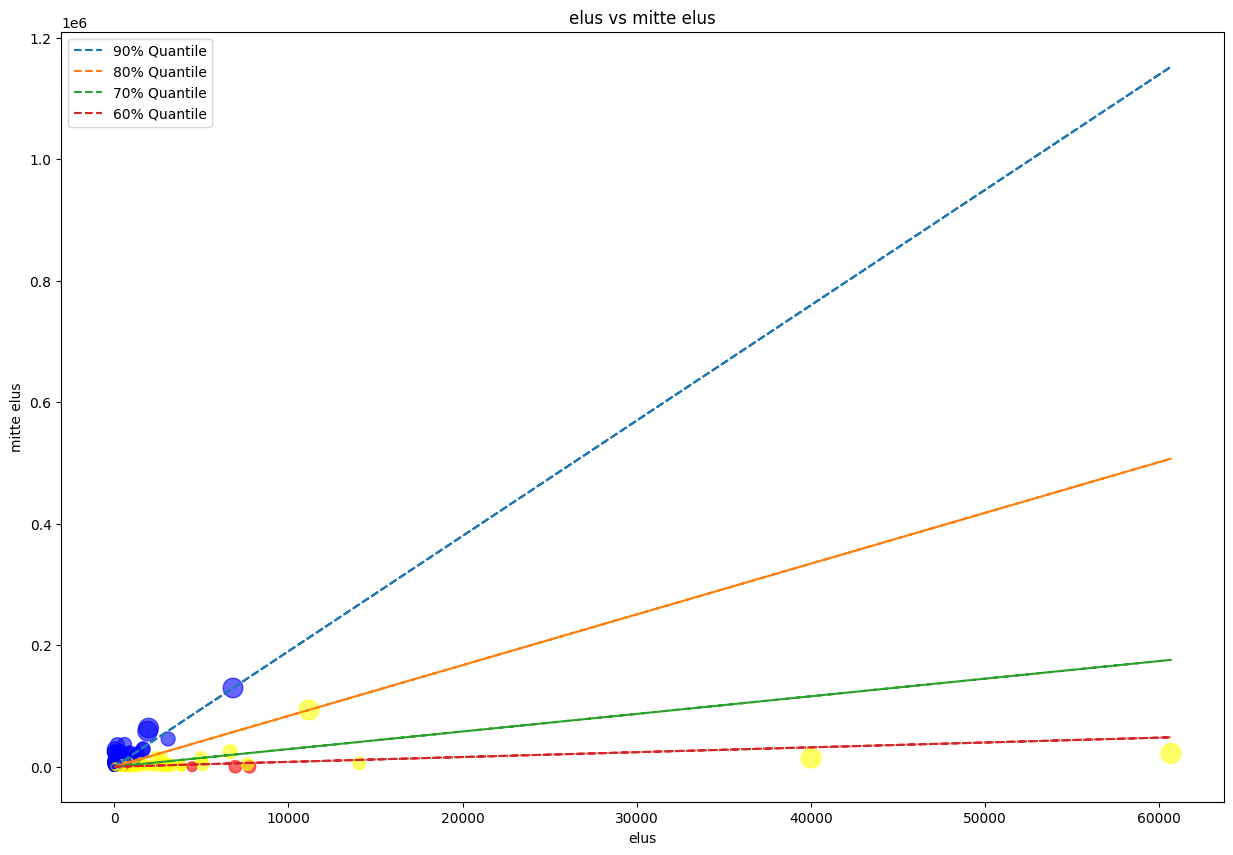

In [15]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
color = [colors[cnt] for cnt in words]
plt.scatter(x, y, s=area, c=color, alpha=0.6) #, label="data")

quantiles = [0.9, 0.8, 0.7, 0.6]

# mitte elus 
X = sm.add_constant(x)
for q in quantiles:
    model = sm.QuantReg(y, X).fit(q=q)
    y_pred = model.predict(X)
    plt.plot(x, y_pred, linestyle='--', label=f'{int(q*100)}% Quantile')


plt.title("elus vs mitte elus")
plt.ylabel("mitte elus")
plt.xlabel("elus")
plt.legend()
plt.show()

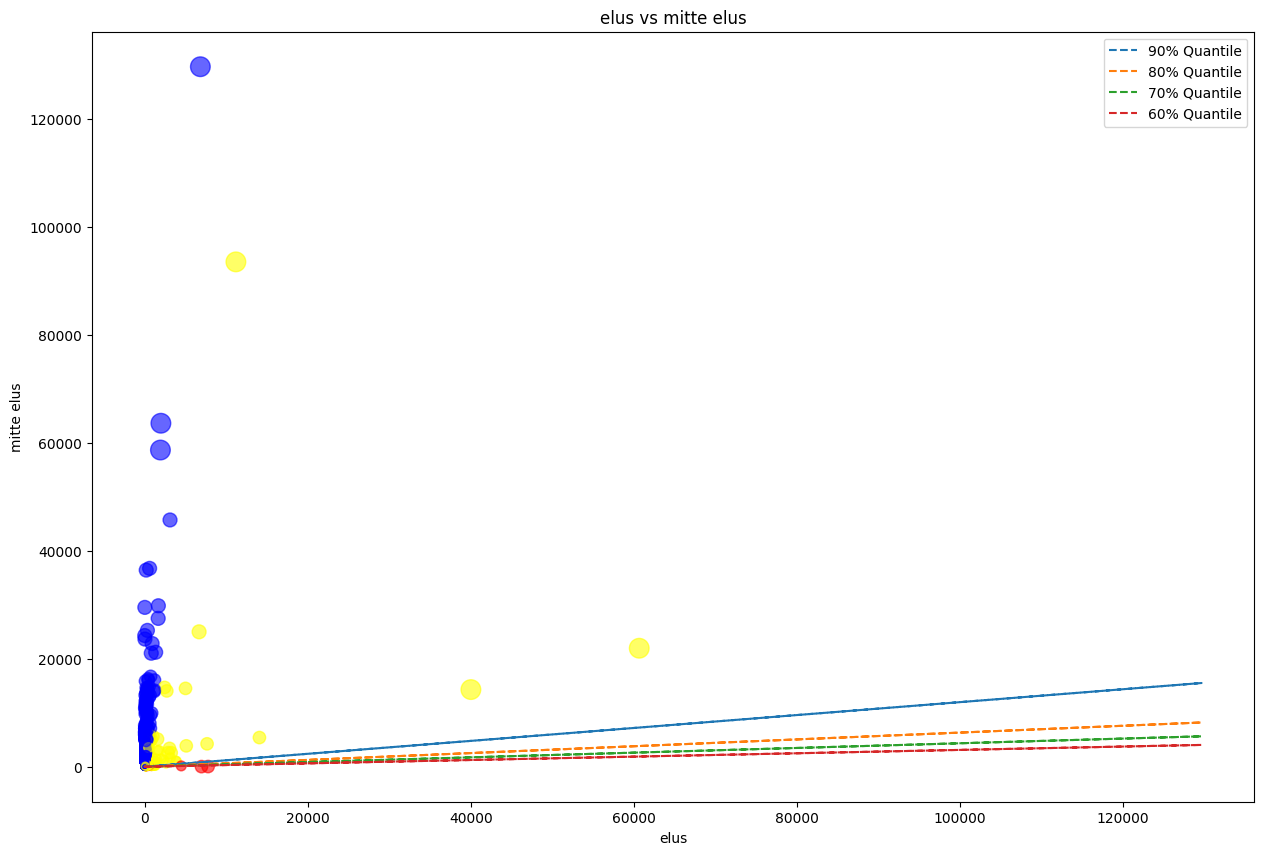

In [28]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
color = [colors[cnt] for cnt in words]
plt.scatter(x, y, s=area, c=color, alpha=0.6) #, label="data")

quantiles = [0.9, 0.8, 0.7, 0.6]

# elus
Y = sm.add_constant(y)
for q in quantiles:
    model = sm.QuantReg(x, Y).fit(q=q)
    x_pred = model.predict(Y)
    plt.plot(y,x_pred,linestyle='--', label=f'{int(q*100)}% Quantile')

plt.title("elus vs mitte elus")
plt.ylabel("mitte elus")
plt.xlabel("elus")
plt.legend()
plt.show()

In [ ]:
con.close()